Initial Plaquette Avg: -0.011445598883514799
Sweep 100: Plaquette Avg = 0.4144, Acceptance Rate = 92.0%
Sweep 200: Plaquette Avg = 0.3984, Acceptance Rate = 92.2%
Sweep 300: Plaquette Avg = 0.4713, Acceptance Rate = 92.2%
Sweep 400: Plaquette Avg = 0.4376, Acceptance Rate = 92.4%
Sweep 500: Plaquette Avg = 0.4405, Acceptance Rate = 91.8%


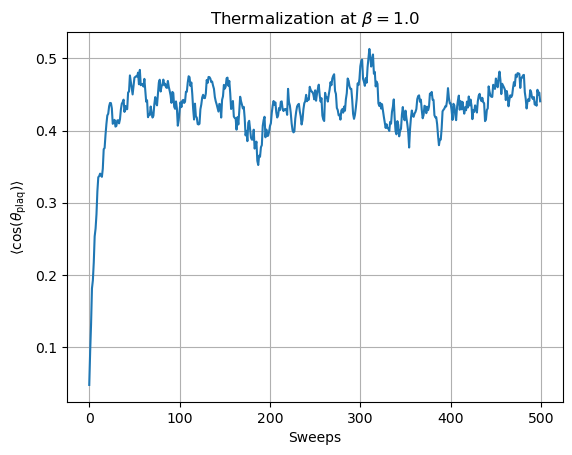

NameError: name 'dS' is not defined

In [10]:
import numpy as np
import matplotlib.pyplot as plt

L = 24
beta = 1.0      # Set higher beta (weak coupling -> strong alignment)
sweeps = 500
epsilon = 0.4   # Step size for proposals

# Initialize Hot Start
np.random.seed() # For reproducible results
theta = np.random.uniform(-np.pi, np.pi, size=(2, L, L))

def compute_plaquettes(theta):
    theta_x = theta[0]
    theta_y = theta[1]
    theta_y_shift_x = np.roll(theta_y, shift=-1, axis=0) # (x+1, y)
    theta_x_shift_y = np.roll(theta_x, shift=-1, axis=1) # (x, y+1)
    return theta_x + theta_y_shift_x - theta_x_shift_y - theta_y

def sweep_metropolis(theta, beta, epsilon):
    accepted = 0
    total_proposals = 2 * L * L
    
    for mu in range(2):
        for x in range(L):
            for y in range(L):
                old_val = theta[mu, x, y]
                delta = np.random.uniform(-epsilon, epsilon)
                new_val = old_val + delta
                    
                # Evaluate local plaquettes using modulo L for periodic boundaries
                if mu == 0:  # x-link at (x,y)
                    # Plaquette above (x,y)
                    p1_old = theta[0, x, y] + theta[1, (x+1)%L, y] - theta[0, x, (y+1)%L] - theta[1, x, y]
                    # Plaquette below (x,y)
                    p2_old = theta[0, x, (y-1)%L] + theta[1, (x+1)%L, (y-1)%L] - theta[0, x, y] - theta[1, x, (y-1)%L]
                    
                    theta[mu, x, y] = new_val
                    p1_new = theta[0, x, y] + theta[1, (x+1)%L, y] - theta[0, x, (y+1)%L] - theta[1, x, y]
                    p2_new = theta[0, x, (y-1)%L] + theta[1, (x+1)%L, (y-1)%L] - theta[0, x, y] - theta[1, x, (y-1)%L]
                else:       # y-link at (x,y)
                    # Plaquette right of (x,y)
                    p1_old = theta[0, x, y] + theta[1, (x+1)%L, y] - theta[0, x, (y+1)%L] - theta[1, x, y]
                    # Plaquette left of (x,y)
                    p2_old = theta[0, (x-1)%L, y] + theta[1, x, y] - theta[0, (x-1)%L, (y+1)%L] - theta[1, (x-1)%L, y]
                    
                    theta[mu, x, y] = new_val
                    p1_new = theta[0, x, y] + theta[1, (x+1)%L, y] - theta[0, x, (y+1)%L] - theta[1, x, y]
                    p2_new = theta[0, (x-1)%L, y] + theta[1, x, y] - theta[0, (x-1)%L, (y+1)%L] - theta[1, (x-1)%L, y]
                
                # Delta S = -beta * sum(cos(new) - cos(old))
                dS = -beta * ((np.cos(p1_new) + np.cos(p2_new)) - (np.cos(p1_old) + np.cos(p2_old)))
                
                # Metropolis decision rule
                if dS > 0 and np.random.rand() > np.exp(-dS):
                    theta[mu, x, y] = old_val # Reject step
                else:
                    accepted += 1
                    
    return accepted / total_proposals

# Run thermalization
history = []
print("Initial Plaquette Avg:", np.mean(np.cos(compute_plaquettes(theta))))

for step in range(sweeps):
    acc_rate = sweep_metropolis(theta, beta, epsilon)
    avg_p = np.mean(np.cos(compute_plaquettes(theta)))
    history.append(avg_p)
    if (step + 1) % 100 == 0:
        print(f"Sweep {step+1}: Plaquette Avg = {avg_p:.4f}, Acceptance Rate = {acc_rate*100:.1f}%")

plt.plot(history)
plt.ylabel(r"$\langle \cos(\theta_{\mathrm{plaq}}) \rangle$")
plt.xlabel("Sweeps")
plt.title(f"Thermalization at $\\beta={beta}$")
plt.grid(True)
plt.show()